# Assignment-7: Exploratory Data Analysis

In [28]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",50)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

sns.set_theme(style="whitegrid",palette="muted")
FIGSIZE =  (12 ,5)
TARGET = "churn"


In [29]:
# importing data

df = pd.read_csv("/Users/pradyumreddygade/AI ML Course Projects/Lectures/Banking_churn_prediction.csv")

print("-" * 60)
print("Shape:" , df.shape)
print("-" * 60)



------------------------------------------------------------
Shape: (28382, 21)
------------------------------------------------------------


In [30]:
print("\n First 5 Rows")
print("-" * 60)
df.head()


 First 5 Rows
------------------------------------------------------------


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.000,self_employed,187.000,2,755,1458.710,1458.710,1458.710,1449.070,0.200,0.200,0.200,0.200,1458.710,1458.710,0,2019-05-21
1,2,2348,35,Male,0.000,self_employed,NaN,2,3214,5390.370,8704.660,7799.260,12419.410,0.560,0.560,5486.270,100.560,6496.780,8787.610,0,2019-11-01
2,4,2194,31,Male,0.000,salaried,146.000,2,41,3913.160,5815.290,4910.170,2815.940,0.610,0.610,6046.730,259.230,5006.280,5070.140,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.000,2,582,2291.910,2291.910,2084.540,1006.540,0.470,0.470,0.470,2143.330,2291.910,1669.790,1,2019-08-06
4,6,1579,42,Male,2.000,self_employed,1494.000,3,388,927.720,1401.720,1643.310,1871.120,0.330,714.610,588.620,1538.060,1157.150,1677.160,1,2019-11-03


In [31]:
print("\n Data Types")
print("-" * 60)

df.dtypes


 Data Types
------------------------------------------------------------


customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

In [32]:
print("\n Basic Stats of Numeric Columns")
print("-" * 60)

df.describe(include=[np.number])


 Basic Stats of Numeric Columns
------------------------------------------------------------


,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000,28382.000,28382.000,25919.000,27579.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000,28382.000
mean,15143.509,2091.144,48.208,0.347,796.110,2.226,925.975,7380.552,7495.771,7496.780,7124.209,3433.252,3261.694,3658.745,3339.761,7451.133,7495.177,0.185
std,8746.454,272.677,17.807,0.998,432.872,0.660,937.799,42598.712,42529.345,41726.219,44575.810,77071.452,29688.889,51985.424,24301.112,42033.939,42431.979,0.389
min,1.000,73.000,1.000,0.000,0.000,1.000,1.000,-5503.960,-3149.570,1428.690,-16506.100,0.010,0.010,0.010,0.010,-3374.180,-5171.920,0.000
25%,7557.250,1958.000,36.000,0.000,409.000,2.000,176.000,1784.470,1906.000,2180.945,1832.507,0.310,0.330,0.410,0.410,1996.765,2074.407,0.000
50%,15150.500,2154.000,46.000,0.000,834.000,2.000,572.000,3281.255,3379.915,3542.865,3359.600,0.610,0.630,91.930,109.960,3447.995,3465.235,0.000
75%,22706.750,2292.000,60.000,0.000,1096.000,3.000,1440.000,6635.820,6656.535,6666.887,6517.960,707.272,749.235,1360.435,1357.553,6667.958,6654.693,0.000
max,30301.000,2476.000,90.000,52.000,1649.000,3.000,4782.000,5905904.030,5740438.630,5700289.570,5010170.100,12269845.390,2361808.290,7637857.360,1414168.060,5778184.770,5720144.500,1.000


In [33]:
print("\n Basic Stats of Categirical Columns")
print("-" * 60)

df.describe(include="object")


 Basic Stats of Categirical Columns
------------------------------------------------------------


,gender,occupation,last_transaction
count,27857,28302,28382
unique,2,5,361
top,Male,self_employed,NaT
freq,16548,17476,3223


In [39]:
print("-" * 60)
print("Data Quality Audit")
print("-" * 60)

print("Missing Values")
print("-" * 60)

missing = pd.DataFrame({
"missing_count" : df.isnull().sum()
,"missing_pct" : df.isnull().mean() * 100
}).query("missing_count > 0").sort_values("missing_pct", ascending= False)

print(missing if not missing.empty else "No missing values")

------------------------------------------------------------
Data Quality Audit
------------------------------------------------------------
Missing Values
------------------------------------------------------------
            missing_count  missing_pct
dependents           2463        8.678
city                  803        2.829
gender                525        1.850
occupation             80        0.282


In [76]:
print("Duplicate Rows")
print("-" * 60)

duplicated_rows = df.duplicated().sum()
print(f"\n Duplicated Rows: {duplicated_rows} ({duplicated_rows/len(df)*100: .2f}%) ")

Duplicate Rows
------------------------------------------------------------

 Duplicated Rows: 0 ( 0.00%) 


In [44]:
print("Cardinality Check for categorical columns")
print("-" * 60)

cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f" {col} : {df[col].nunique()} unique | sample : {df[col].unique()[:5]}")

Cardinality Check for categorical columns
------------------------------------------------------------
 gender : 2 unique | sample : ['Male' nan 'Female']
 occupation : 5 unique | sample : ['self_employed' 'salaried' 'retired' 'student' nan]
 last_transaction : 361 unique | sample : ['2019-05-21' '2019-11-01' 'NaT' '2019-08-06' '2019-11-03']


In [53]:
print("Target Class Balanace")
print("-" * 60)

target_dist = df[TARGET].value_counts(normalize=True) * 100
print(target_dist)

if target_dist.min() < 15:
    print("Class imbalanced Data")

Target Class Balanace
------------------------------------------------------------
churn
0   81.467
1   18.533
Name: proportion, dtype: float64


In [74]:
print("Outlier Detection")
print("-" * 60)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ["customer_id" , TARGET]]

for col in numerical_cols:
    Q1 , Q3 = df[col].quantile([0.25 , 0.75])
    IQR = Q3 -Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    if n_out > 0:
        print(f" {col}: {n_out} outliers ({n_out/len(df)*100: .1f}%)")



Outlier Detection
------------------------------------------------------------
 vintage: 945 outliers ( 3.3%)
 dependents: 4484 outliers ( 15.8%)
 branch_code: 699 outliers ( 2.5%)
 current_balance: 2739 outliers ( 9.7%)
 previous_month_end_balance: 2731 outliers ( 9.6%)
 average_monthly_balance_prevQ: 2727 outliers ( 9.6%)
 average_monthly_balance_prevQ2: 2612 outliers ( 9.2%)
 current_month_credit: 4558 outliers ( 16.1%)
 previous_month_credit: 4682 outliers ( 16.5%)
 current_month_debit: 3935 outliers ( 13.9%)
 previous_month_debit: 4075 outliers ( 14.4%)
 current_month_balance: 2697 outliers ( 9.5%)
 previous_month_balance: 2720 outliers ( 9.6%)


Univariate Analysis for Numerical Cols
------------------------------------------------------------


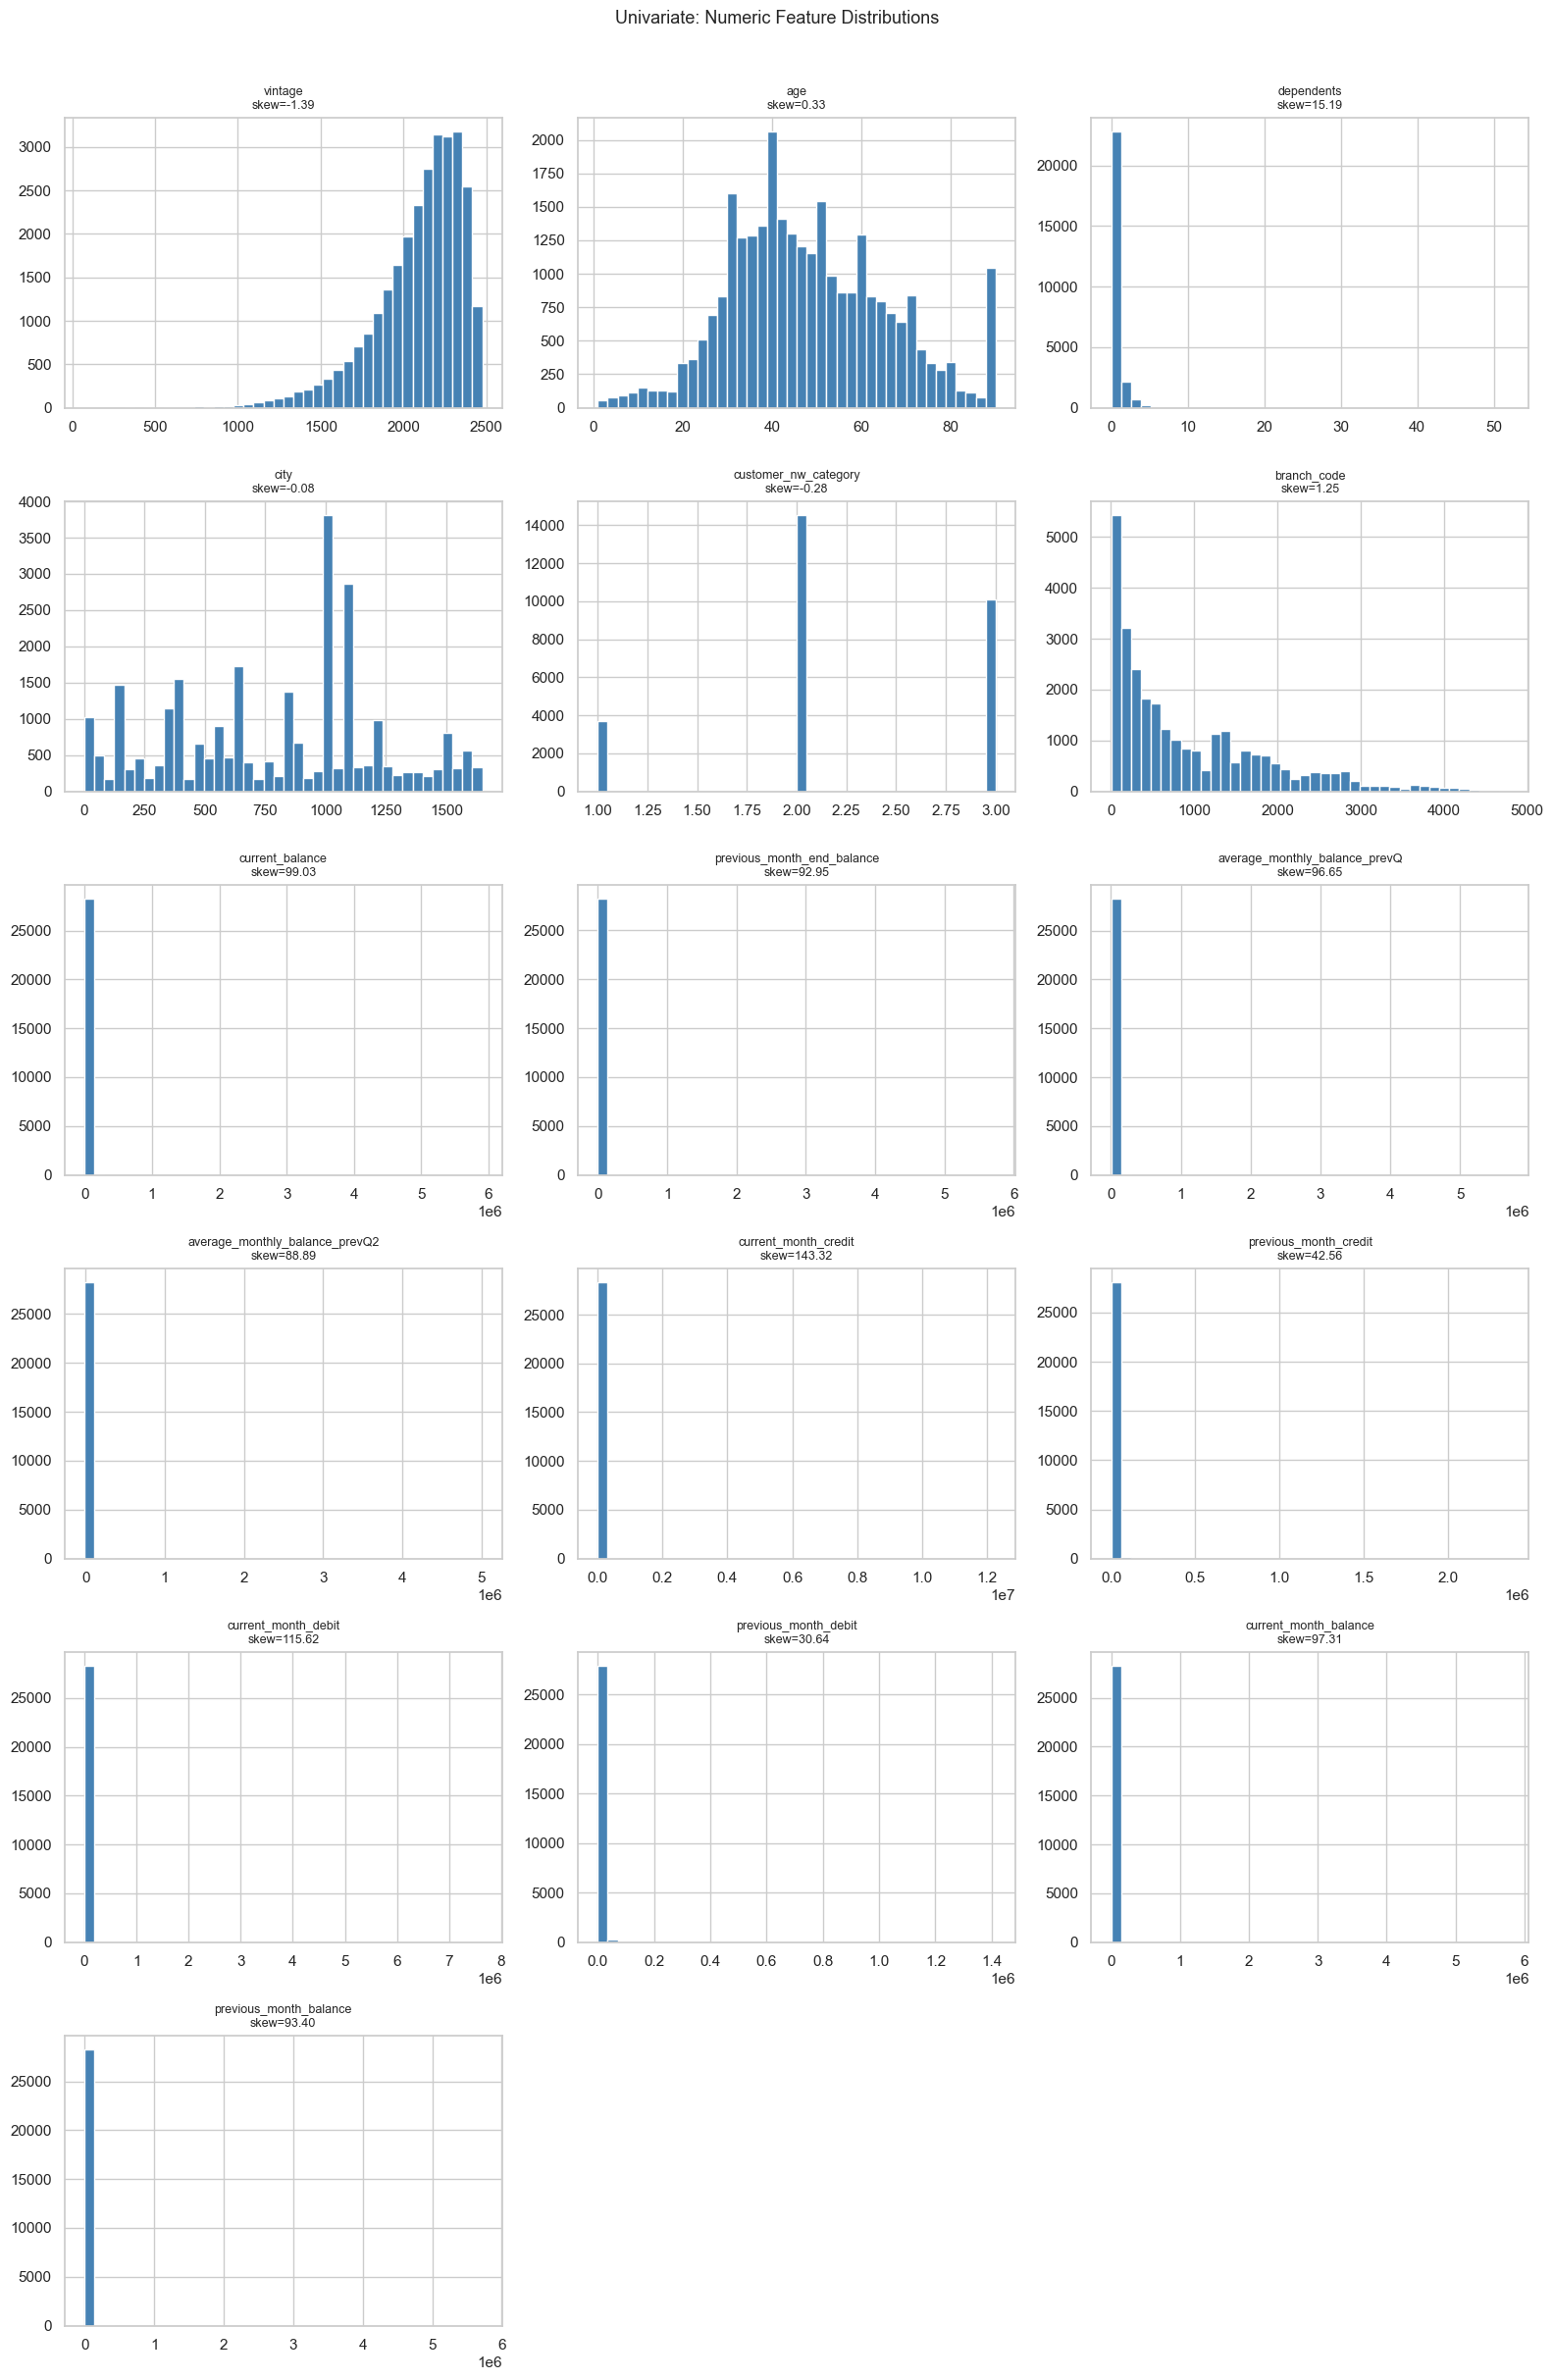

In [78]:
print("Univariate Analysis for Numerical Cols")
print("-" * 60)

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}", fontsize=9)
    axes[i].set_xlabel("")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Univariate: Numeric Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Univariate Analysis for Categirical Cols
------------------------------------------------------------


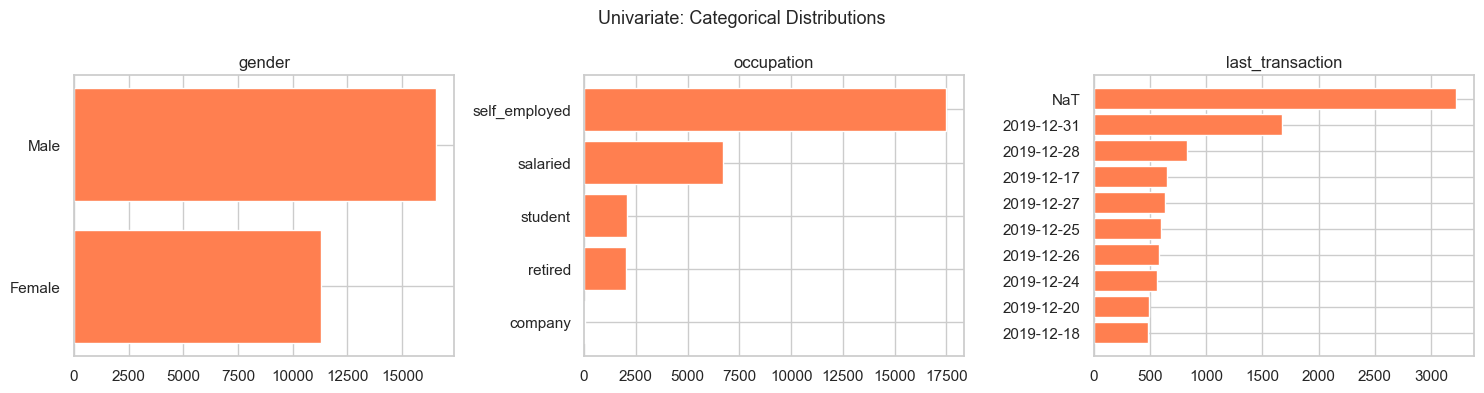

In [65]:
print("Univariate Analysis for Categirical Cols")
print("-" * 60)

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        vc = df[col].value_counts()
        ax.barh(vc.index[:10], vc.values[:10], color="coral")
        ax.set_title(col)
        ax.invert_yaxis()
    plt.suptitle("Univariate: Categorical Distributions", fontsize=13)
    plt.tight_layout()
    plt.show()

Bivariate Analysis for Numerical Cols VS Target
------------------------------------------------------------


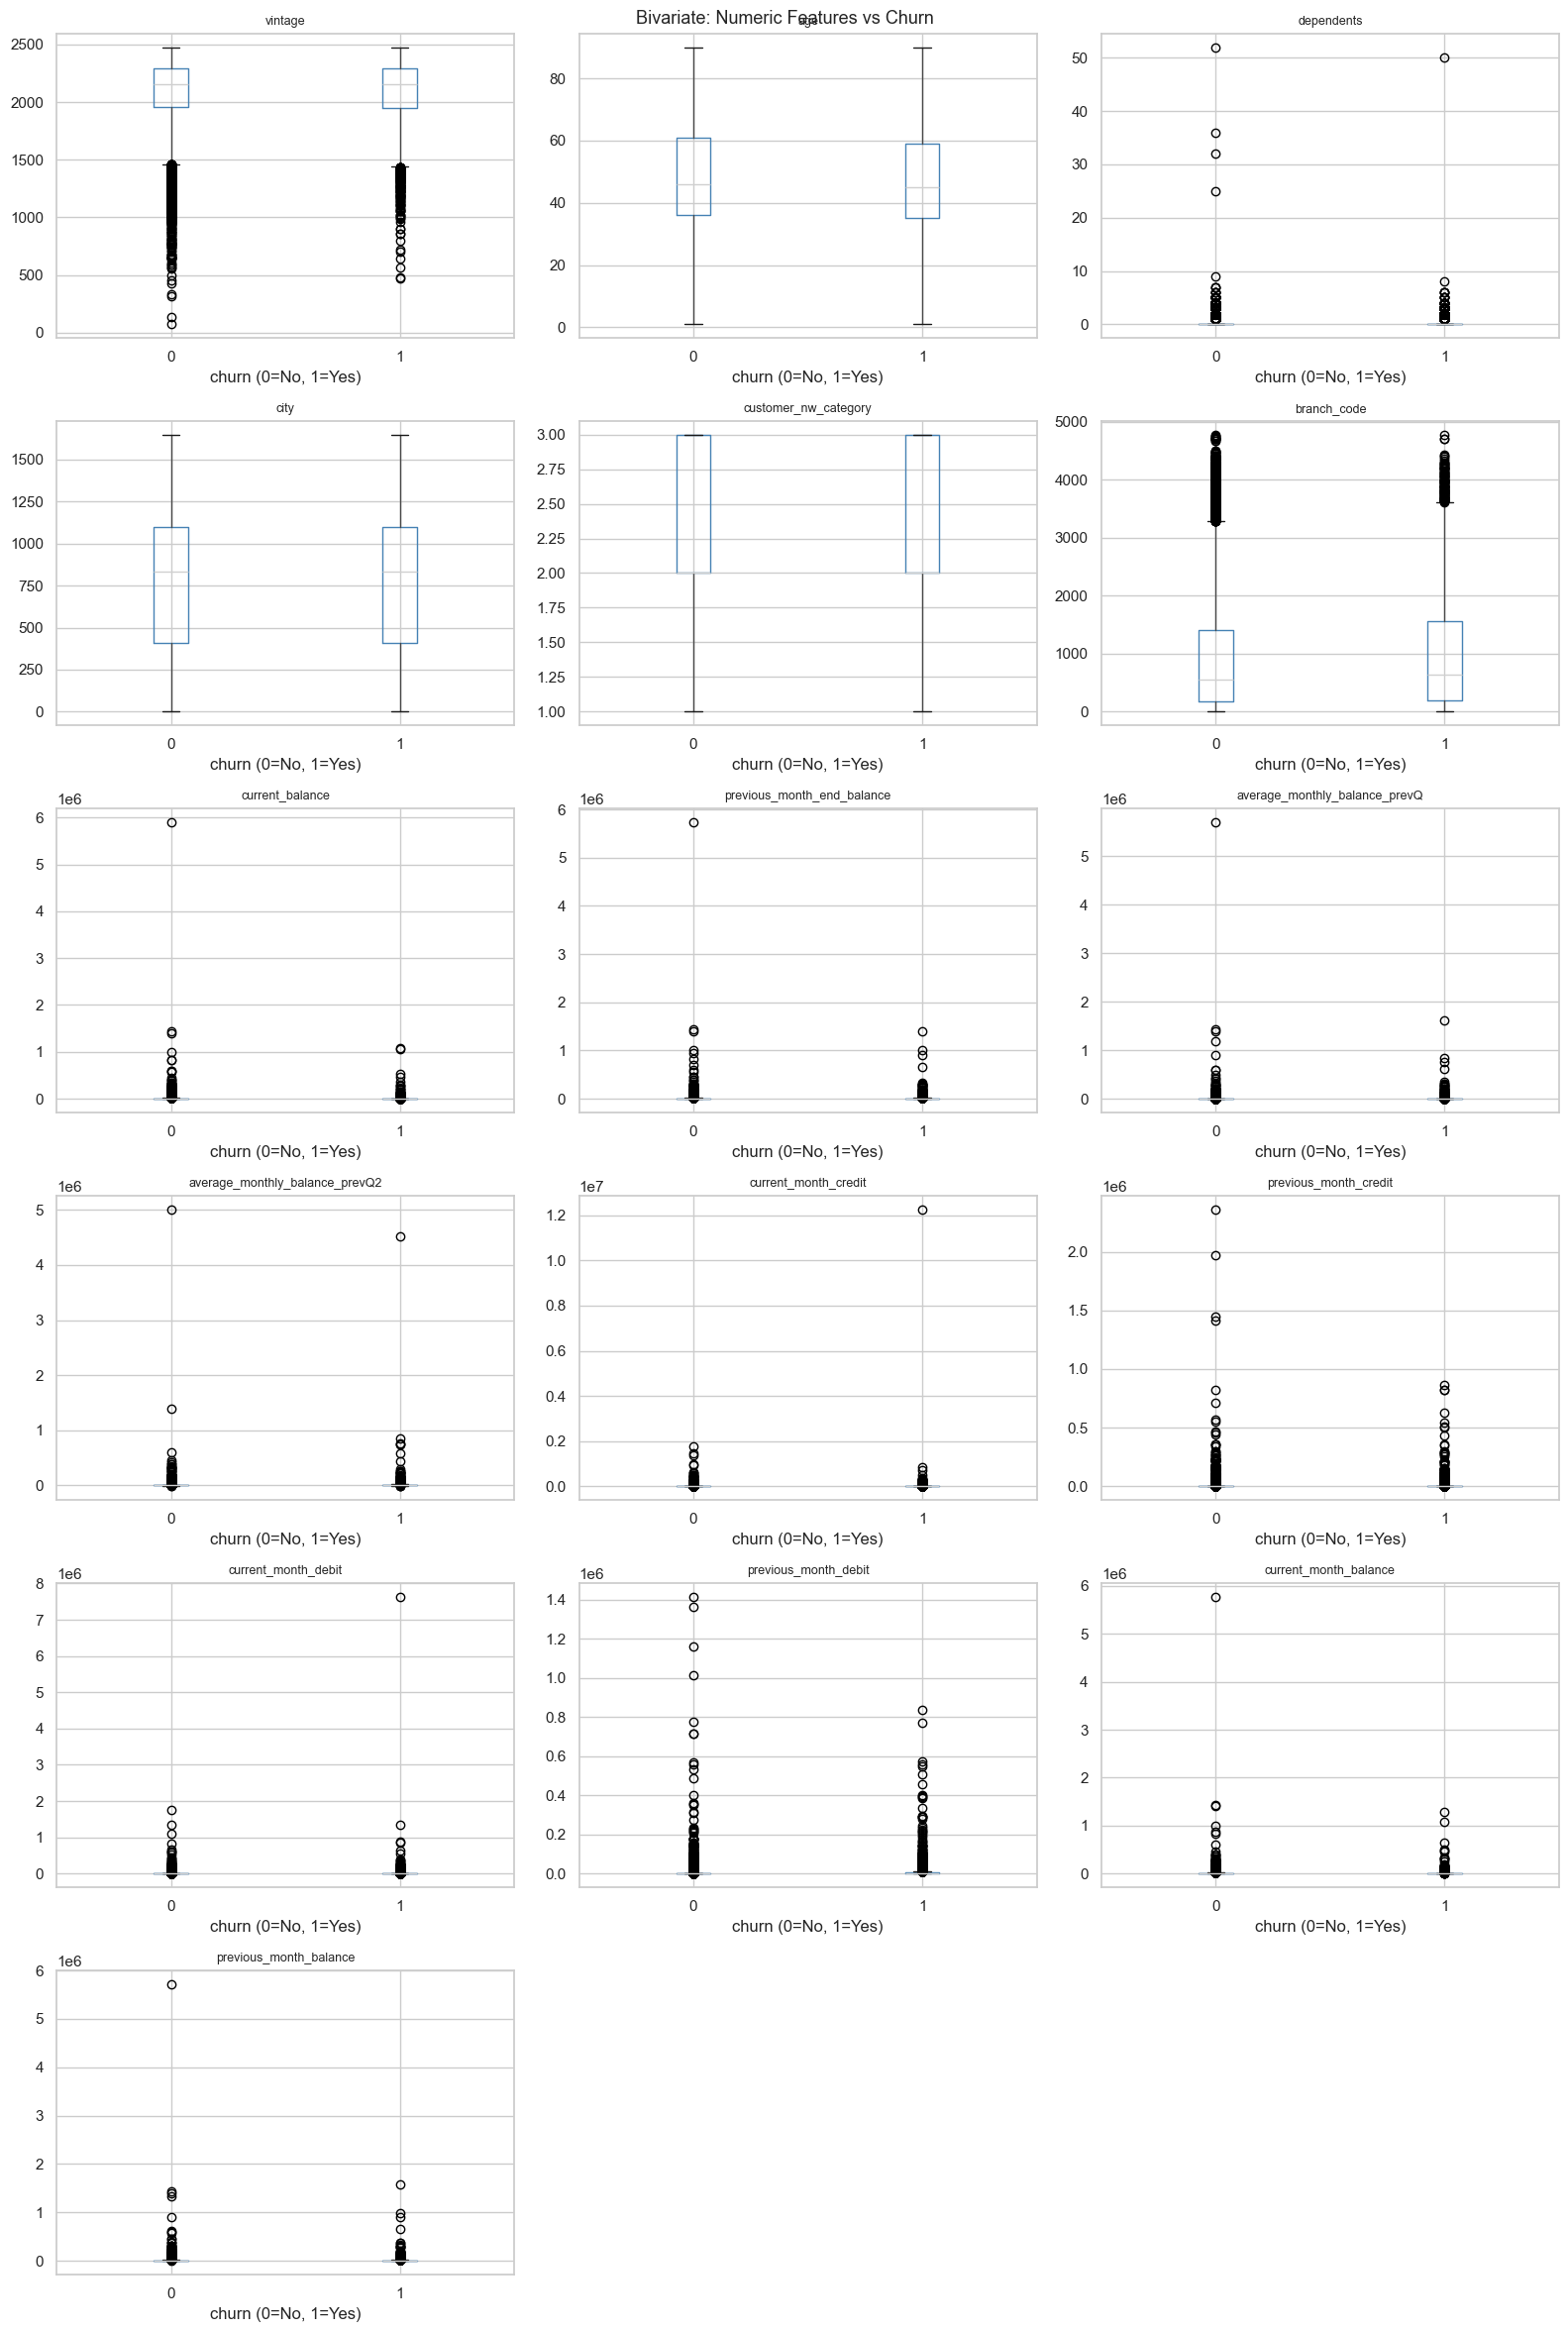

In [66]:
print("Bivariate Analysis for Numerical Cols VS Target")
print("-" * 60)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by=TARGET, ax=axes[i], 
               boxprops=dict(color="steelblue"))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("churn (0=No, 1=Yes)")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Bivariate: Numeric Features vs Churn", fontsize=13)
plt.tight_layout()
plt.savefig("bivariate_numeric_vs_churn.png", bbox_inches="tight")
plt.show()

In [68]:
print("Bivariate Analysis for Categorical Cols VS Target")
print("-" * 60)

if cat_cols:
    print("\n--- Churn Rate by Category ---")
    for col in cat_cols:
        tbl = (df.groupby(col)[TARGET]
                 .mean()
                 .sort_values(ascending=False)
                 .rename("churn_rate")
                 .reset_index())
        print(tbl.to_string(index=False), "\n")

Bivariate Analysis for Categorical Cols VS Target
------------------------------------------------------------

--- Churn Rate by Category ---
gender  churn_rate
  Male       0.192
Female       0.176 

   occupation  churn_rate
self_employed       0.198
     salaried       0.171
      student       0.157
      retired       0.151
      company       0.100 

last_transaction  churn_rate
      2019-01-31       1.000
      2019-09-30       1.000
      2019-08-19       1.000
      2019-07-29       1.000
      2019-02-13       1.000
      2019-07-01       1.000
      2019-04-01       1.000
      2019-02-11       0.500
      2019-09-09       0.500
      2019-08-26       0.500
      2019-07-27       0.462
      2019-09-23       0.400
      2019-09-29       0.400
      2019-03-24       0.364
      2019-01-17       0.333
      2019-10-21       0.333
      2019-04-15       0.333
      2019-04-12       0.333
      2019-10-05       0.313
      2019-07-11       0.311
      2019-09-26       0.308
  

Correlation heatmap (numeric features only)
------------------------------------------------------------


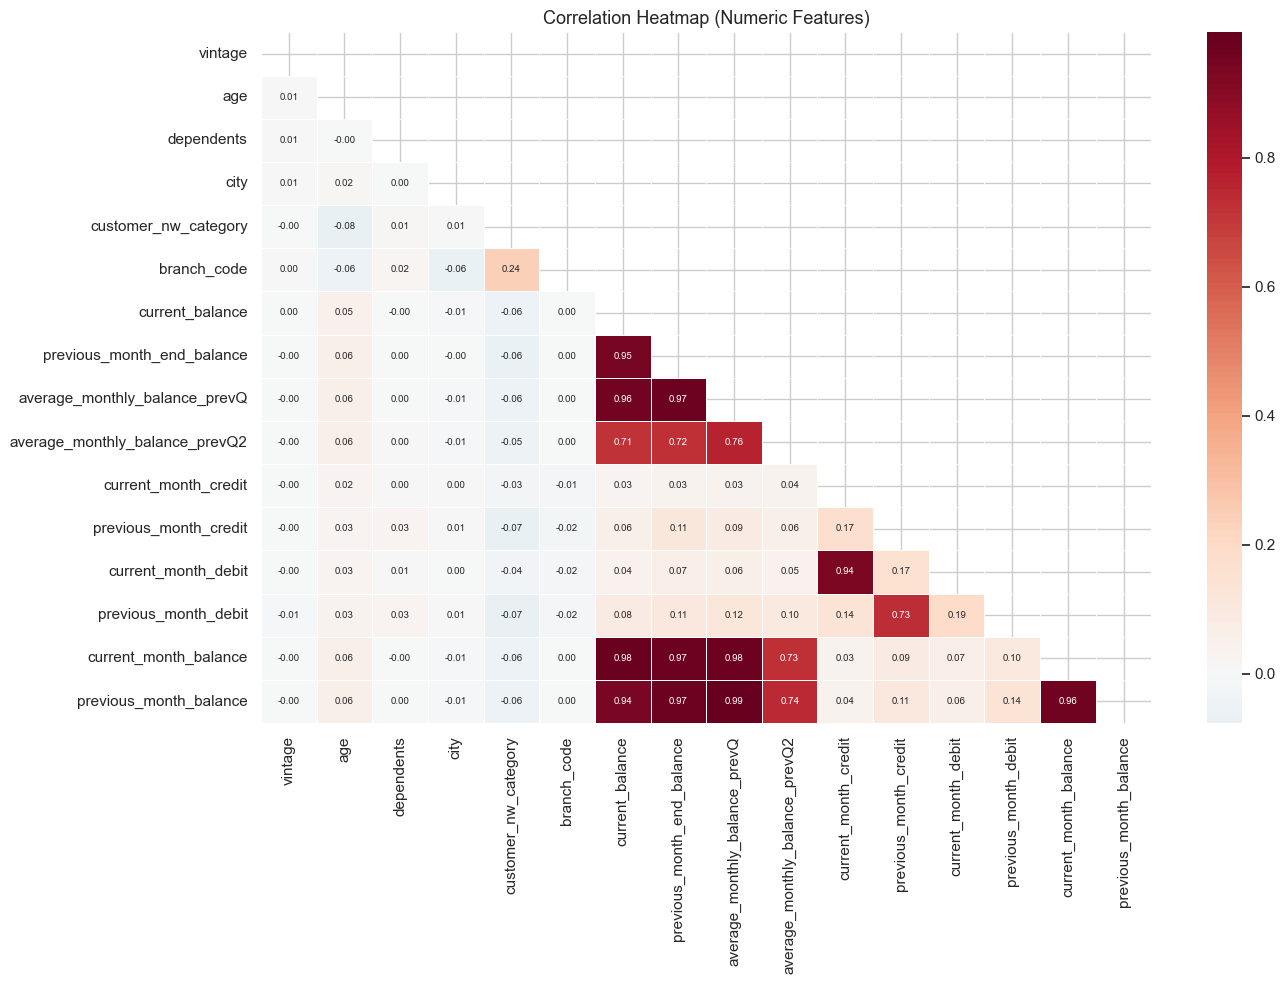

In [72]:
print("Correlation heatmap (numeric features only)")
print("-" * 60)

plt.figure(figsize=(14, 10))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap (Numeric Features)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()